# Tutorial: a coupled culvert from one `.inp`

This walkthrough builds a small **coupled** model — 2D overland flow (ANUGA)
over a channel with a culvert under a road, plus a 1D sewer — driven entirely
from a single SWMM `.inp` via {func}`~anuga_drainage.couple_from_inp`. We run it
on **both** backends (pipedream and SWMM) and compare the exchange flows and the
node water levels.

```{note}
This notebook is executed locally when the docs are built (it needs ANUGA,
pyswmm and pipedream); on Read the Docs it renders the stored outputs.
```


In [86]:
%matplotlib inline
import os, tempfile, textwrap
import numpy as np
import matplotlib.pyplot as plt
import anuga
from anuga_drainage import couple_from_inp

## The sewer network

A tiny culvert: water enters at **Inlet**, flows through a box **Culvert** under
the road to **Outlet**, then down an **Outpipe** to the free **Outfall**. We
write it as a SWMM `.inp` — the standard format both backends understand. The
`[OPTIONS]` block (simulation dates, units, routing step) is what SWMM needs;
pipedream ignores it and reads only the network sections.

In [87]:
INP = textwrap.dedent('''\
    [TITLE]
    Tutorial culvert

    [OPTIONS]
    FLOW_UNITS           CMS
    INFILTRATION         HORTON
    FLOW_ROUTING         DYNWAVE
    LINK_OFFSETS         DEPTH
    START_DATE           01/01/2024
    START_TIME           00:00:00
    END_DATE             01/01/2024
    END_TIME             00:30:00
    REPORT_START_DATE    01/01/2024
    REPORT_START_TIME    00:00:00
    REPORT_STEP          00:00:01
    ROUTING_STEP         0.1
    IGNORE_RAINFALL      YES

    [JUNCTIONS]
    ;;Name  Elev  MaxDepth  InitDepth  Sur  Aponded
    Inlet   0.07  2.0       0          0    0
    Outlet  0.03  2.0       0          0    0

    [OUTFALLS]
    Outfall 0.00  FREE                 NO

    [CONDUITS]
    ;;Name   From    To       Length  Rough  InOff  OutOff  Init  Max
    Culvert  Inlet   Outlet   11.0    0.013  0      0       0     0
    Outpipe  Outlet  Outfall  5.0     0.013  0      0       0     0

    [XSECTIONS]
    Culvert  RECT_CLOSED  1.0   4.0   0   0   1
    Outpipe  CIRCULAR     0.6   0     0   0   1

    [COORDINATES]
    Inlet    21.0   10.0
    Outlet    9.0   10.0
    Outfall   3.0   10.0
    ''')

inp_path = os.path.join(tempfile.mkdtemp(), 'culvert.inp')
with open(inp_path, 'w') as f:
    f.write(INP)
print(INP)

[TITLE]
Tutorial culvert

[OPTIONS]
FLOW_UNITS           CMS
INFILTRATION         HORTON
FLOW_ROUTING         DYNWAVE
LINK_OFFSETS         DEPTH
START_DATE           01/01/2024
START_TIME           00:00:00
END_DATE             01/01/2024
END_TIME             00:30:00
REPORT_START_DATE    01/01/2024
REPORT_START_TIME    00:00:00
REPORT_STEP          00:00:01
ROUTING_STEP         0.1
IGNORE_RAINFALL      YES

[JUNCTIONS]
;;Name  Elev  MaxDepth  InitDepth  Sur  Aponded
Inlet   0.07  2.0       0          0    0
Outlet  0.03  2.0       0          0    0

[OUTFALLS]
Outfall 0.00  FREE                 NO

[CONDUITS]
;;Name   From    To       Length  Rough  InOff  OutOff  Init  Max
Culvert  Inlet   Outlet   11.0    0.013  0      0       0     0
Outpipe  Outlet  Outfall  5.0     0.013  0      0       0     0

[XSECTIONS]
Culvert  RECT_CLOSED  1.0   4.0   0   0   1
Outpipe  CIRCULAR     0.6   0     0   0   1

[COORDINATES]
Inlet    21.0   10.0
Outlet    9.0   10.0
Outfall   3.0   10.0



## The 2D domain

A 60 m x 20 m channel with a raised road across the middle (x = 10-20 m); the
culvert carries water under it. Water is injected at the right-hand end and
drains through a Dirichlet boundary on the left. We wrap it in a function so we
can build a fresh domain for each backend (a domain can't be re-run after
`evolve`). The mesh is kept coarse so the notebook runs quickly.

In [88]:
def build_domain():
    rf = 10
    domain = anuga.rectangular_cross_domain(3 * rf, rf, len1=60, len2=20)
    domain.set_name('tutorial')

    def topography(x, y):
        z = 5 * np.ones_like(x)
        channel = (y > 4.25) & (y < 15.75)
        z = np.where(channel & (x < 10), x / 300, z)   # low channel downstream
        z = np.where(channel & (x > 20), x / 300, z)   # low channel upstream
        return z                                       # raised road for 10 < x < 20

    domain.set_quantity('elevation', topography, location='centroids')
    domain.set_quantity('friction', 0.035)

    inflow = anuga.Inlet_operator(domain, [[59.0, 5.0], [59.0, 15.0]], 1.0)
    Br = anuga.Reflective_boundary(domain)
    Bd = anuga.Dirichlet_boundary([-1.0, 0, 0])
    domain.set_boundary({'left': Bd, 'bottom': Br, 'top': Br, 'right': Br})
    return domain, inflow

## The geometry of the problem

Before running, let's look at the layout: the triangular mesh and the
topography, with the sewer nodes (read straight from the `.inp`) and the
upstream inflow line drawn on top. Water ponds in the channel upstream of the
raised road (the light band across the middle) and the **Culvert** carries it
under the road from **Inlet** to **Outlet**, discharging at the **Outfall**.

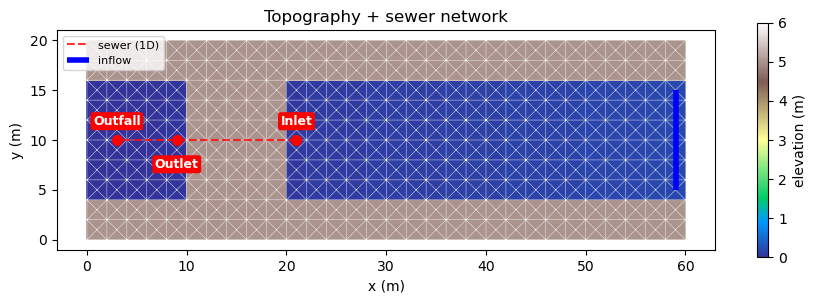

In [103]:
import matplotlib.tri as mtri
from anuga_drainage.inp import read_inp

geo_domain, _ = build_domain()
triang = mtri.Triangulation(geo_domain.nodes[:, 0], geo_domain.nodes[:, 1],
                            geo_domain.triangles)
elev = geo_domain.quantities['elevation'].centroid_values

# Sewer node coordinates straight from the .inp [COORDINATES] section.
coords = read_inp(inp_path).coordinates.set_index('node')

# Stack the two panels (the domain is long and thin, 60 x 20 m).
fig, ax_elev = plt.subplots(1, 1, figsize=(9, 7))

# ax_mesh.triplot(triang, lw=0.3, color='0.6')
# ax_mesh.set_title('Mesh'); ax_mesh.set_aspect('equal')
# ax_mesh.set_ylabel('y (m)')

tpc = ax_elev.tripcolor(triang, facecolors=elev, cmap='terrain', vmin=0.0, vmax=6.0)
fig.colorbar(tpc, ax=ax_elev, label='elevation (m)', shrink=0.35)
ax_elev.triplot(triang, lw=0.3, color='1.0')

# The 1D sewer drawn on the surface: Inlet -> Culvert -> Outlet -> Outpipe ->
# Outfall (dashed = underground), plus the upstream inflow line.
order = ['Inlet', 'Outlet', 'Outfall']
px = [coords.loc[n, 'x'] for n in order]
py = [coords.loc[n, 'y'] for n in order]
ax_elev.plot(px, py, 'r--', lw=1.5, alpha=0.8, label='sewer (1D)')
ax_elev.plot([59, 59], [5, 15], 'b-', lw=4, label='inflow', solid_capstyle='butt')
for k, name in enumerate(order):
    x, y = coords.loc[name, 'x'], coords.loc[name, 'y']
    ax_elev.plot(x, y, 'o', color='red', ms=7)
    dy = 11 if k % 2 == 0 else -20           # stagger labels so they don't collide
    ax_elev.annotate(name, (x, y), textcoords='offset points', xytext=(0, dy),
                     ha='center', color='white', fontsize=9, fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.2', fc='red', ec='none'))
ax_elev.set_title('Topography + sewer network'); ax_elev.set_aspect('equal')
ax_elev.set_xlabel('x (m)'); ax_elev.set_ylabel('y (m)')
ax_elev.legend(loc='upper left', fontsize=8)
fig.tight_layout()

## Run on each backend

`run(backend)` builds a fresh domain, couples it from the **same** `.inp`,
attaches a volume-balance audit, and records the exchange flux `Q` (surface →
pipe) and the pipe head at each coupled node every step. `coupling.step(dt)`
drives the exchange and the audit together.

In [107]:
def run(backend, record_frames=False):
    domain, inflow = build_domain()
    # Give the Inlet/Outlet a footprint that spans the channel: the .inp only
    # carries a point per junction, so the auto polygon can be too narrow and flow
    # overtops the embankment instead of being captured into the culvert.
    coupling = couple_from_inp(domain, inp_path, backend=backend,
                               inlet_polygons={
                                   'Inlet':  [[20, 6], [22, 6], [22, 14], [20, 14]],
                                   'Outlet': [[8, 6], [10, 6], [10, 14], [8, 14]],
                               },
                               time_average=20.0, clamp=True,
                               internal_links=10, pipedream_max_step=0.01)
    coupling.add_volume_balance(inflow_operators=[inflow])

    domain.set_omp_num_threads(3)  # use multiple CPU cores for the surface flow (if available)

    # pipedream is sub-second capable, so use a finer coupling step — a smaller dt
    # shrinks the surface<->pipe handoff residual R_couple (it closes to the
    # coupling's discretisation order). SWMM is restricted to whole-second strides
    # (int(dt)), so it stays at 1 s.
    dt = 0.5 if backend == 'pipedream' else 1.0
    frame_every = max(1, round(12.0 / dt))  # save a depth frame ~every 12 s (~20 frames)

    # Optionally record 2D depth frames for an animation (one backend is enough;
    # the surface flow is essentially the same — the backends differ in the 1D
    # network). Domain_plotter wraps the live domain; frames go to a temp dir.
    plotter = None
    if record_frames:
        frame_dir = os.path.join(tempfile.mkdtemp(), 'frames')
        plotter = anuga.Domain_plotter(domain, plot_dir=frame_dir, min_depth=0.05)

    t, Q, head = [], [], []
    for i, time in enumerate(domain.evolve(yieldstep=dt, finaltime=240.0)):
        step = coupling.step(dt)
        if plotter is not None and i % frame_every == 0:
            plotter.save_depth_frame(vmin=0.0, vmax=0.25, figsize=(9, 3.5), dpi=80)
        t.append(time)
        Q.append(np.asarray(step.Q_in).copy())            # exchange flux per node
        head.append(coupling.backend.get_heads().copy())  # pipe head per node
    coupling.close()
    return dict(names=list(coupling.inlets), t=np.array(t),
                Q=np.array(Q), head=np.array(head), vb=coupling.volume_balance,
                plotter=plotter)

animation_backend = 'pipedream'  # 'swmm' also works but is slower to run and record frames
res = {backend: run(backend, record_frames=(backend == animation_backend))
       for backend in ('pipedream', 'swmm')}
names = res[animation_backend]['names']
print('coupled nodes:', names)

Setting omp_num_threads to 3
Figure files for each frame will be stored in /tmp/tmpvznazjmc/frames
Setting omp_num_threads to 3
coupled nodes: ['Inlet', 'Outlet']


## Watch the surface flow

An animation of the 2D water depth over the run (grey = dry topography, colour =
water depth). Water floods down the channel from the right, ponds against the
road, and drains through the culvert to the downstream side — exactly the
overland behaviour the 1D culvert is coupled to. (Rendered with ANUGA's
`Domain_plotter`; the frames were captured in the loop above.)

In [108]:
from matplotlib import rc
rc('animation', html='jshtml')   # embed the animation inline (and in the docs)

res[animation_backend]['plotter'].make_depth_animation()

## Compare the exchange flows

The exchange flux `Q` at each node — positive is water leaving the 2D surface
and entering the pipe. The two solvers track each other closely; differences
come from how each routes flow through the 1D network.

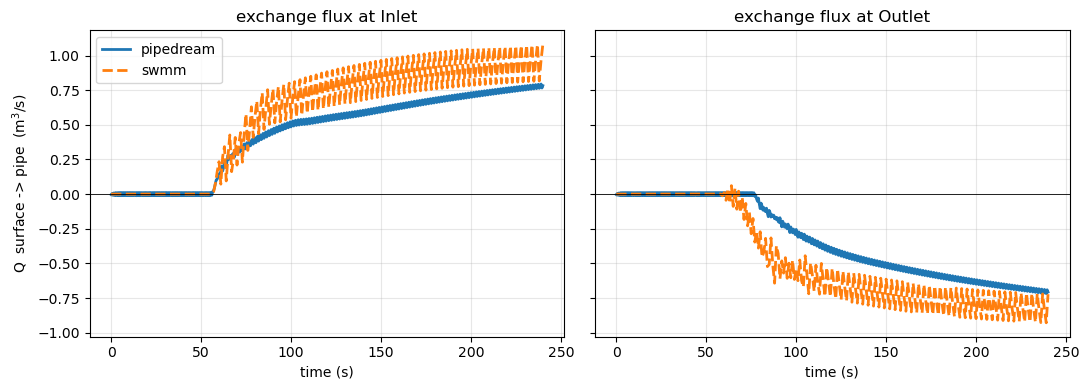

In [109]:
fig, axes = plt.subplots(1, len(names), figsize=(11, 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, i, name in zip(axes, range(len(names)), names):
    for backend, style in [('pipedream', '-'), ('swmm', '--')]:
        ax.plot(res[backend]['t'], res[backend]['Q'][:, i], style, lw=2, label=backend)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title(f'exchange flux at {name}')
    ax.set_xlabel('time (s)')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Q  surface -> pipe  (m$^3$/s)')
axes[0].legend()
fig.tight_layout()

## Compare the node water levels

The pipe head at each node over time, for both backends — you can see water
filling the pipe and the system settling.

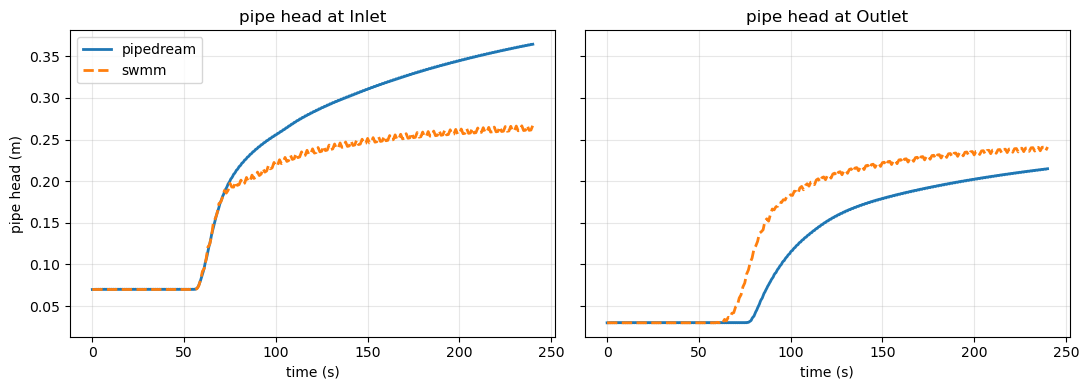

In [110]:
fig, axes = plt.subplots(1, len(names), figsize=(11, 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, i, name in zip(axes, range(len(names)), names):
    for backend, style in [('pipedream', '-'), ('swmm', '--')]:
        ax.plot(res[backend]['t'], res[backend]['head'][:, i], style, lw=2, label=backend)
    ax.set_title(f'pipe head at {name}')
    ax.set_xlabel('time (s)')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('pipe head (m)')
axes[0].legend()
fig.tight_layout()

## Did they conserve?

The audit splits the mass balance into ANUGA, the pipe solver, and the coupling
handoff. `R_anuga` is ~machine precision for both (ANUGA is finite-volume); the
small remaining residuals have clear, separate origins:

- **`R_pipe`** — the 1D solver's own non-conservation: SWMM's finite-difference
  loss, and pipedream's small surcharge/linearisation residual.
- **`R_couple`** — the surface↔pipe handoff. For SWMM it is ~0 (SWMM reports the
  flow it actually accepted). For pipedream it is a small residual that **closes
  to the coupling's discretisation order**: pipedream credits the pipe with the
  requested exchange, while ANUGA applies it on the *next* evolve, so one step of
  water is momentarily "in flight". It shrinks with the coupling step — that is
  why this run drives pipedream at `dt = 0.5 s` (SWMM stays at the whole-second
  `dt = 1 s` its stepping requires).

In [111]:
for backend in ('pipedream', 'swmm'):
    print(f'================  {backend}  ================')
    summary = res[backend]['vb'].summary()
    print(summary.split('--- per inlet')[0].rstrip())
    print()

================  pipedream  ================
Volume balance at t = 240 s
  ANUGA water    V_anuga =   147.977442  (start 0.000000)
  pipe water     V_pipe  =    22.567408  (start 0.001140)
  inflow source          =   240.000000
  boundary flux          =   -66.197100
  inlets -> ANUGA        =   -25.825458
  inlets -> pipe         =    25.833833
  outfall <- pipe        =     3.352408
  --- residuals (should be ~0) ---
  R_anuga  (ANUGA closes)     =  4.263e-13
  R_pipe   (pipe closes)      =  8.484e-02
  R_couple (handoff consistent)=  8.375e-03
  total loss = R_anuga+R_pipe+R_couple =  9.322e-02

================  swmm  ================
Volume balance at t = 240 s
  ANUGA water    V_anuga =   116.182632  (start 0.000000)
  pipe water     V_pipe  =     9.194893  (start 0.001351)
  inflow source          =   240.000000
  boundary flux          =   -99.634718
  inlets -> ANUGA        =   -24.182649
  inlets -> pipe         =    24.182649
  outfall <- pipe        =    15.297070
  --- r

## Recap

From **one** `.inp` we built the sewer and the coupling, ran it on both
pipedream and SWMM, and compared the exchange flows and node water levels — with
the volume audit confirming conservation on each. Same file, same loop, swap one
argument.
